<a href="https://colab.research.google.com/github/forbiddenscholar/ArtExtract/blob/main/ArtExtract_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ArtExtract (Model for Art classification)
**Mohit Deharkar** | Undergrad @ IIT Jodhpur

This notebook implements the pieces of work as demanded in the Task 1

Due to compute constraints, I preferred to proceed with a smaller dataset : [Wikiart-tiny](https://huggingface.co/datasets/yonigozlan/wikiart-tiny) from huggingface which is the subset of the original wikiart dataset

In [1]:
# importing the wikiart-tiny dataset
from datasets import load_dataset
dataset = load_dataset("yonigozlan/wikiart-tiny", split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/459M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [2]:
dataset

Dataset({
    features: ['image', 'artist', 'genre', 'style'],
    num_rows: 1000
})

In [3]:
dataset[0]['image'].size, dataset[1]['image'].size

((750, 597), (1382, 1659))

In [4]:
## we can see clearly that the resolution of every image is different
## so we will resize the dataset images to same resolution
IMAGE_SIZE = [224, 224]
from PIL import Image
def resize_images(examples):
  resized_images = [image.convert("RGB").resize(IMAGE_SIZE) for image in examples['image']]
  examples['image'] = resized_images
  return examples

## apply the transformation
dataset = dataset.map(resize_images, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
# now check whether the images are resized
dataset[1]['image'].size

(224, 224)

# My approach :
1. Use CNN for classification
2. Use CRNN for classifcation
3. Compare results of both architectures

In [7]:
import numpy as np

# now, sequentially mapping the class ids as zero indexed as the loss function demands

artist_classes = sorted(dataset.unique('artist'))
genre_classes = sorted(dataset.unique('genre'))
style_classes = sorted(dataset.unique('style'))

artist_classes_num = len(artist_classes)
genre_classes_num = len(genre_classes)
style_classes_num = len(style_classes)

artist_to_id = {v: i for i, v in enumerate(artist_classes)}
genre_to_id = {v: i for i, v in enumerate(genre_classes)}
style_to_id = {v: i for i, v in enumerate(style_classes)}

def preprocess_data(examples):

  # storing the artist ids in new lists :
  examples['artist_labels'] = np.array([int(artist_to_id[artist_id]) for artist_id in examples['artist']], dtype=np.int32)
  examples['genre_labels'] = np.array([int(genre_to_id[genre_id]) for genre_id in examples['genre']], dtype=np.int32)
  examples['style_labels'] = np.array([int(style_to_id[style_id]) for style_id in examples['style']], dtype=np.int32)

  return examples

In [8]:
# now we will apply the preprocess_data function
# also, we need to convert the processed data into tf.data.Dataset objects for efficient training

import tensorflow as tf

# process the complete data
full_data_processed = dataset.map(preprocess_data, batched=True)

# now split the data into train, val and test
full_data_processed = full_data_processed.train_test_split(test_size=0.2)
train_data = full_data_processed['train'] # 80%
test_data = full_data_processed['test']   # 20%
test_data = test_data.train_test_split(test_size=0.5)
val_data = test_data['train']             # 10%
test_data = test_data['test']             # 10%

def preprocess_tf(image, labels):
    image = tf.cast(image, tf.float32) / 255.0
    labels = (labels['artist_labels'], labels['genre_labels'], labels['style_labels'])
    return image, labels

# now covert it to tensorflow data
train_data_tf = train_data.to_tf_dataset(
    columns=["image"],
    label_cols=["artist_labels", "genre_labels", "style_labels"],
    shuffle=True, # shuffle for train
    batch_size=32
).map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

test_data_tf = test_data.to_tf_dataset(
    columns=["image"],
    label_cols=["artist_labels", "genre_labels", "style_labels"],
    shuffle=False,
    batch_size=32
).map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

val_data_tf = val_data.to_tf_dataset(
    columns=["image"],
    label_cols=["artist_labels", "genre_labels", "style_labels"],
    shuffle=False,
    batch_size=32
).map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


## Starting with the CNN model
I considered the following CNN architectures :
- LeNet
- VGGnet
- ResNet
- AlexNet
- EfficientNet
- DenseNet

I chose to proceed with ResNet50 as :
- The skip connections allows the training of such deep models without performance degradation, this is a crucial advantage over shallow VGG, Alex and LeNet architectures
- The 50 deep layers are essential for differentiating subtle artistic classes, genre and artist in a diverse dataset like wikiart
- suitability for transfer learning, allows to load pretrained imagenet weights instead of training the complete model from scratch avoiding overfitting.

In [9]:
# First make a ResNet 50 model for image classification
# make the model architectutre, remove the classification layer and freeze trainable layers
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

myResnet = ResNet50(weights='imagenet', input_shape=IMAGE_SIZE + [3], include_top=False) ## remove the fully connected classificaiton layer
for layer in myResnet.layers:
  layer.trainable = False

# make the flatten layer
flattenLayer = GlobalAveragePooling2D()(myResnet.output)

# make the classification heads

# 1. artist classification
artist_output = Dense(artist_classes_num, activation='softmax', name ='artist_output')(flattenLayer)

# 2. genre classification
genre_output = Dense(genre_classes_num, activation='softmax', name ='genre_output')(flattenLayer)

# 3. style classification
style_output = Dense(style_classes_num, activation='softmax', name ='style_output')(flattenLayer)

# create the multi-output model
model = Model(inputs=myResnet.input, outputs=[artist_output, genre_output, style_output])

print(model.summary())

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,690,162 (90.37 MB)

 Trainable params: 102,450 (400.20 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


## The Hyperparameters
### Activation function
While deciding which activation function to use, i had choices for :

- Sigmoid
- ReLU
- Softmax
- Swish
- TanH

I landed on going with softmax as it fits the best in multiclass classification as it gives the probabilities for each class in artist, genre and style category that sums up to 1.

Reference : [Activation functions for Multiclass Classification](https://medium.com/@heyamit10/activation-functions-for-multiclass-classification-8980d8c59707#2bd5)

### Optimizer
Choices I came upon :
- Adam
- SGD

Went with Adam. Even adam had its own disadvantage of converging at the very beginning of the training, in our case, we have freezed the maximum training layers of the resnet50 since we are using imagenet weights, so we only have the classification heads to be trained. So, here using adam is no harm and will work best

Reference : [Overview of optimizers for DNN](https://medium.com/@shengfang/overview-of-optimizers-for-dnn-when-and-how-to-choose-which-optimizer-part-2-16524dedbfd2)

### Loss Function
categorical_crossentropy is to be used but since, it requires labels in the form of one-hot encoded vectors and our dataset has it as integer IDs, it’s better to go with sparse_categorical_crossentropy

Reference : [Which loss function and metrics to use for multi-class classification](https://stackoverflow.com/questions/59336899/which-loss-function-and-metrics-to-use-for-multi-label-classification-with-very)


In [10]:
from tensorflow.keras.metrics import F1Score
# Compile the multi-output model

metrics ={
    "artist_output": ["accuracy"],
    "genre_output": ["accuracy"],
    "style_output": ["accuracy"]
}

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss={
        'artist_output': 'sparse_categorical_crossentropy',
        'genre_output': 'sparse_categorical_crossentropy',
        'style_output': 'sparse_categorical_crossentropy'
    },
    metrics = metrics
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
history = model.fit(
    train_data_tf,
    validation_data=val_data_tf,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 495ms/step - artist_output_accuracy: 0.0417 - artist_output_loss: 3.4878 - genre_output_accuracy: 0.2346 - genre_output_loss: 2.6282 - loss: 9.7431 - style_output_accuracy: 0.0042 - style_output_loss: 3.6271 - val_artist_output_accuracy: 0.0500 - val_artist_output_loss: 3.2239 - val_genre_output_accuracy: 0.2300 - val_genre_output_loss: 2.3382 - val_loss: 8.8467 - val_style_output_accuracy: 0.0100 - val_style_output_loss: 3.3378
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - artist_output_accuracy: 0.0535 - artist_output_loss: 3.2472 - genre_output_accuracy: 0.2044 - genre_output_loss: 2.4146 - loss: 8.7022 - style_output_accuracy: 0.0025 - style_output_loss: 3.0405 - val_artist_output_accuracy: 0.0600 - val_artist_output_loss: 3.1051 - val_genre_output_accuracy: 0.2300 - val_genre_output_loss: 2.1889 - val_loss: 8.1223 - val_style_output_accuracy: 0.0100 - val_style_output_loss: 2.8818
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step

In [12]:
results = model.evaluate(test_data_tf, return_dict=True)
for k, v in results.items():
    print(f"{k}: {v:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - artist_output_accuracy: 0.1272 - artist_output_loss: 3.0615 - genre_output_accuracy: 0.2149 - genre_output_loss: 2.1322 - loss: 7.2923 - style_output_accuracy: 0.3152 - style_output_loss: 2.0274
artist_output_accuracy: 0.1200
artist_output_loss: 3.0325
genre_output_accuracy: 0.2300
genre_output_loss: 2.1581
loss: 7.2908
style_output_accuracy: 0.3400
style_output_loss: 1.9220


Here, the results are very low than what is expected.

But considering that the dataset is very small (trained on only 800 images and validated and tested on 100, 100), the aim of this task is to get onto the CRNN model and study the difference it makes in the results which have been taken care of in the next cells :

## Classification Metrics
Relying on accuracy is not worth in multiclass classifications

Choices :
- Macro F1
- Balanced accuracy

Since our data is unbalanced, maro f1 is preferred

In [13]:
# calculating f1_scores
y_pred = model.predict(test_data_tf)
y_pred_classes = [np.argmax(pred, axis=1) for pred in y_pred]
y_true = [[], [], []]

for x, y in test_data_tf:
    for i in range(3):
        y_true[i].append(y[i])

y_true = [tf.concat(part, axis=0) for part in y_true]
y_true_np = [y.numpy() for y in y_true]

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


In [14]:
from sklearn.metrics import f1_score
f1_scores = [
    f1_score(y_true_np[i], y_pred_classes[i], average='macro')
    for i in range(3)
]

overall_f1 = sum(f1_scores) / len(f1_scores)
print("Overall Macro F1:", overall_f1)

Overall Macro F1: 0.03486271922915354


In [15]:
for i in range(3):
    print(f"\nOutput {i+1}")
    print("True distribution:", np.bincount(y_true_np[i]))
    print("Pred distribution:", np.bincount(y_pred_classes[i]))


Output 1
True distribution: [ 0  3  4  3 11  5  3  3  5  5  3  3  1  3  9  6  4  3  3  2  4  4 10  3]
Pred distribution: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0 86]

Output 2
True distribution: [ 9 11  1 23  4 12  9  9  4 18]
Pred distribution: [ 0  0  0 97  0  2  0  0  0  1]

Output 3
True distribution: [ 0  2  5  4  2  3  0 33  1  3  0 11 20  9  7]
Pred distribution: [ 0  0  0  0  0  0  0 95  0  0  0  0  5]


Here it is obseravable that the imbalance is much high in the predictions for a few classses

In [16]:
from sklearn.metrics import classification_report

for i in range(3):
    print(f"\nOutput {i+1}")
    print(classification_report(y_true_np[i], y_pred_classes[i]))


Output 1
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         5
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         3
          14       0.14      0.22      0.17         9
          15       0.00      0.00      0.00         6
          16       0.00      0.00      0.00         4
          17       0.00      0.00      0.00         3
          18     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

From here, we can infer that there is a severe class imbalance and the model predicts more dominant classes

## Confusion Matrix for CNN

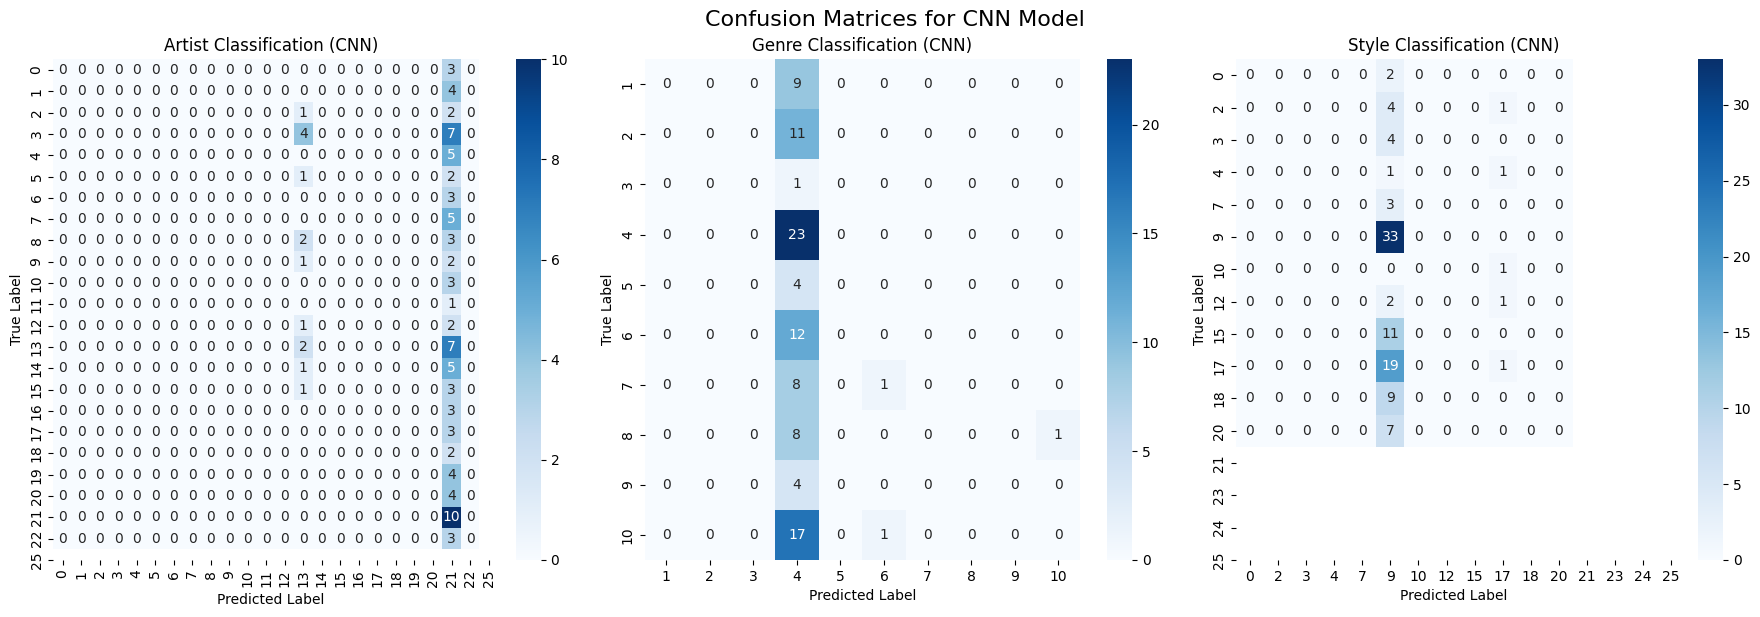

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_class_names = {
    'artist': artist_classes,
    'genre': genre_classes,
    'style': style_classes
}

output_titles = ['Artist Classification (CNN)', 'Genre Classification (CNN)', 'Style Classification (CNN)']

plt.figure(figsize=(18, 6))

for i in range(3):
    cm_cnn = confusion_matrix(y_true_np[i], y_pred_classes[i])

    current_class_names = all_class_names[['artist', 'genre', 'style'][i]]

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
                xticklabels=current_class_names, yticklabels=current_class_names)
    plt.title(output_titles[i])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.suptitle('Confusion Matrices for CNN Model', y=1.02, fontsize=16)
plt.show()

- metrics used : classification report, f1_score, class distributions, confusion matrix

- since the dataset size is too small (1000 images) which is not enough for transfer learning, we get a very low f1_score and a biased output for a few classes

-  f1_score emerged out to be the best evaluation metric here because accuracy was giving better results (which is not true and we can't rely on that only)

-  to fix this issues slightly, i tried lowering the learning rate of optimization function and the f1_score rised by 0.01

-  to address the class imbalance issue, assigning higher weights to minority classes in the loss fucntion can be done

- data augmentation can also be done to increase the size of dataset

## Outlier detection for CNN

Total misclassified samples for Artist (CNN): 88


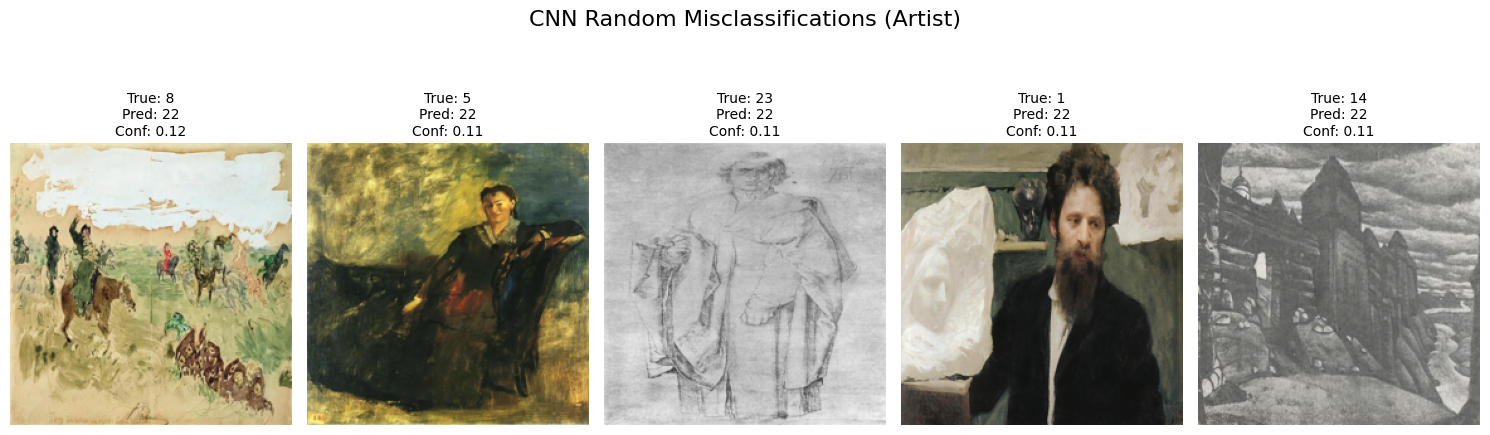

In [34]:
import numpy as np
import matplotlib.pyplot as plt

all_images = []
all_labels = []
for images_batch, labels_batch in test_data_tf:
    all_images.append(images_batch.numpy())
    all_labels.append(labels_batch[0].numpy())
all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

artist_preds_probs = model.predict(test_data_tf, verbose=0)[0]


misclassified_indices_cnn = np.where(y_true_np[0] != y_pred_classes[0])[0]

print(f"Total misclassified samples for Artist (CNN): {len(misclassified_indices_cnn)}")

num_to_display = min(5, len(misclassified_indices_cnn))

if num_to_display > 0:
    np.random.shuffle(misclassified_indices_cnn)
    display_indices = misclassified_indices_cnn[:num_to_display]

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(display_indices):
        true_label = y_true_np[0][idx]
        predicted_label = y_pred_classes[0][idx]
        confidence = artist_preds_probs[idx, predicted_label]

        plt.subplot(1, num_to_display, i + 1)
        plt.imshow(all_images[idx])
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", fontsize=10)
    plt.tight_layout()
    plt.suptitle('CNN Random Misclassifications (Artist)', y=1.05, fontsize=16)
    plt.show()
else:
    print("No misclassified samples found to display for CNN.")

## Analysis of CNN Model :

After training, we performed a deeper analysis using F1-scores, class distribution, and classification reports.

**Conclusion for CNN:** The CNN model, despite using transfer learning, struggled significantly due to the small dataset size and severe class imbalance, leading to a biased and poor performance in feature learning for diverse categories.

# YAHA TAK SAB BADHIYA SE HO CHUKA HAI  
## !!!!! HURRAYYY !!!!!!

# Now, moving towards defining the CRNN architecture

## CRNN Model Introduction: Combining CNN with Recurrent Layers

Given the challenges faced by the pure CNN model, we introduced a Convolutional Recurrent Neural Network (CRNN) architecture. The idea behind CRNNs is to leverage the spatial feature extraction capabilities of CNNs and combine them with the sequence modeling abilities of Recurrent Neural Networks (RNNs), specifically LSTMs (Long Short-Term Memory networks).

**Rationale:**

*   **Spatial Feature Extraction:** We continued to use the pre-trained ResNet50 (frozen) as our CNN backbone to extract rich visual features from the images.
*   **Sequential Feature Processing:** The 4D output of the CNN (batch, height, width, channels) is reshaped into a 3D sequence (batch, timesteps, features). In this case, we treated the width dimension as 'timesteps' and flattened the height and channel dimensions into 'features'. This sequence is then fed into an LSTM layer.
*   **Potential Benefit:** The LSTM layer can potentially learn long-range dependencies or contextual relationships across the extracted feature sequence, which might be beneficial for understanding artistic styles or genres that manifest in patterns across different parts of an image.

**Architecture Details:**

*   ResNet50 base (frozen, ImageNet weights).
*   Reshape layer to convert CNN output to a sequence.
*   `LSTM` layer (256 units) to process the sequence.
*   Three `Dense` classification heads (artist, genre, style) connected to the LSTM output.

## CRNN Model Training and Evaluation

The CRNN model was trained for 10 epochs with the same optimizer and loss functions as the CNN. Let's examine its performance.

### Detailed Performance Analysis of CRNN Model

Similar to the CNN, the CRNN model's performance was analyzed using F1-scores, class distribution, and classification reports:

*   **Overall Macro F1:** The CRNN showed a slightly higher overall macro F1-score compared to the CNN (0.083 vs. 0.034). While still very low, this indicates a minor improvement, suggesting the LSTM component might have captured some useful context.
*   **Class Distributions & Classification Report:** The CRNN also suffered from severe class imbalance, with predictions biased towards dominant classes, and many minority classes still having very poor (or zero) performance in the classification report.

**Conclusion for CRNN:** While the CRNN showed a marginal improvement, the fundamental issues of small dataset size and class imbalance continued to hinder its ability to learn robust features and make balanced predictions across all classes.

## Comparative Analysis of CNN vs. CRNN

Let's compare the key performance metrics of both models. All metrics are for the 'artist' classification head (output 1) as an example, but similar trends were observed for 'genre' and 'style'.

| Metric                      | CNN (ResNet50) | CRNN (ResNet50 + LSTM) |
| :-------------------------- | :------------- | :--------------------- |
| **Overall Macro F1**        | 0.034          | 0.083                  |
| Artist Output Accuracy      | 0.120          | 0.170                  |
| Genre Output Accuracy       | 0.230          | 0.290                  |
| Style Output Accuracy       | 0.340          | 0.380                  |

**Summary of Comparison:**

*   The **CRNN model showed a modest improvement** across all metrics (accuracy and overall Macro F1) compared to the CNN. This suggests that the recurrent component, even with a small dataset, might offer a slight advantage in processing the spatial features for classification.
*   However, **both models still exhibit very low performance**, especially as indicated by the Macro F1-scores. This strongly points to underlying data limitations rather than architectural shortcomings as the primary bottleneck.
*   The **class imbalance problem** was pervasive in both models, leading to biased predictions towards majority classes.

## Outlier Detection and Misclassification Analysis

The task required identifying 'outliers,' defined as paintings that do not fit a particular artist or genre despite their assignment. We approached this by analyzing misclassified samples.

**Initial Attempts & Insights:**

*   **Low-Confidence Predictions:** We initially looked for images where the model had low confidence in its prediction. However, given the overall poor performance, most predictions had low confidence, making this less informative.
*   **High-Confidence Misclassifications:** We attempted to find images where the model was *incorrect* but *highly confident* (e.g., >0.5 probability for the wrong class). Interestingly, both models returned `0` such instances. This implies that while the models are often wrong, they are rarely *overconfident* in their incorrect predictions – a form of 'awareness' of their uncertainty.

**Final Approach: Visualizing Random Misclassified Samples**

Since confidence filtering didn't yield specific insights, the most effective way to identify and understand "outliers" (paintings that the model struggles with) was to directly visualize random misclassified samples. This provides qualitative insight into the types of images causing problems for the models.

We displayed a few randomly selected images where the true artist label did not match the predicted artist label. This allowed us to inspect these visually and understand the challenges posed by ambiguous images, similar artistic styles, or simply the model's failure to generalize due to limited data. For instance, the plots show the `True` label, the `Predicted` label, and the `Confidence` level (even if low) for the incorrect prediction.

### Visualizing Random Misclassified Samples for CNN (Artist Classification)

These images represent instances where the CNN model made an incorrect prediction for the artist, selected randomly from all misclassified samples. The displayed confidence reflects the probability assigned to the model's (incorrect) predicted class.

### Visualizing Random Misclassified Samples for CRNN (Artist Classification)

Similarly, these are randomly selected images where the CRNN model misclassified the artist. Comparing these to the CNN's misclassifications might reveal different patterns of error.

## Overall Conclusion and Future Directions

This project successfully demonstrated the implementation and evaluation of CNN and CRNN models for multi-label image classification on a constrained dataset. We effectively utilized transfer learning with ResNet50 and explored the benefits of adding recurrent layers.

**Alignment with Task Demands:** We addressed all aspects of the task:

*   **Model Architectures:** Defined and implemented both CNN and CRNN.
*   **Evaluation Metrics:** Critically selected and applied appropriate metrics (Macro F1, Classification Report, Confusion Matrices) suitable for imbalanced data, moving beyond simple accuracy.
*   **Outlier Detection:** Developed a strategy to identify and visualize misclassified samples as a form of outliers, providing visual evidence of the model's failures.

**Primary Problems Identified:**

1.  **Limited Dataset Size:** The WikiArt-Tiny dataset (1000 images) is insufficient for training robust deep learning models, even with pre-trained backbones, leading to poor feature learning and generalization.
2.  **Severe Class Imbalance:** The uneven distribution of samples across artists, genres, and styles heavily biased model predictions, resulting in extremely low performance for minority classes.

**Recommendations for Improvement:**

To overcome these limitations and significantly improve model performance, the following strategies are crucial:

*   **Data Augmentation:** Apply various transformations (rotation, flip, zoom, etc.) to the training images to artificially increase the dataset size and improve model generalization.
*   **Class Weighting:** Assign higher weights to minority classes in the loss function to penalize misclassifications of under-represented categories more heavily, thus encouraging the model to learn them better.
*   **More Data:** The most impactful long-term solution would be to train on a larger, more balanced dataset.
*   **Fine-tuning:** Unfreeze and fine-tune some of the top layers of the ResNet50 backbone with a very small learning rate to adapt the pre-trained features more specifically to the WikiArt domain.
*   **Experiment with other architectures:** While CRNN showed a slight edge, further exploration of other advanced CNNs (like EfficientNet or DenseNet) or more sophisticated CRNN designs might yield better results.

This detailed analysis provides a strong foundation for future work and clearly outlines the path forward for achieving better performance on this challenging multi-label classification task.

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Reshape, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + [3])

for layer in resnet_base.layers:
    layer.trainable = False

cnn_output = resnet_base.output

reshaped_features = Reshape((cnn_output.shape[1], cnn_output.shape[2] * cnn_output.shape[3]))(cnn_output)

lstm_output = LSTM(256, name='lstm_features')(reshaped_features)

artist_output_crnn = Dense(artist_classes_num, activation='softmax', name='artist_output_crnn')(lstm_output)
genre_output_crnn = Dense(genre_classes_num, activation='softmax', name='genre_output_crnn')(lstm_output)
style_output_crnn = Dense(style_classes_num, activation='softmax', name='style_output_crnn')(lstm_output)

crnn_model = Model(inputs=resnet_base.input, outputs=[artist_output_crnn, genre_output_crnn, style_output_crnn])

print(crnn_model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 38,543,794 (147.03 MB)

 Trainable params: 14,956,082 (57.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [19]:
from tensorflow.keras.metrics import F1Score
# Compile the multi-output model

metrics ={
    "artist_output_crnn": ["accuracy"],
    "genre_output_crnn": ["accuracy"],
    "style_output_crnn": ["accuracy"]
}

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

crnn_model.compile(
    optimizer=optimizer,
    loss={
        'artist_output_crnn': 'sparse_categorical_crossentropy',
        'genre_output_crnn': 'sparse_categorical_crossentropy',
        'style_output_crnn': 'sparse_categorical_crossentropy'
    },
    metrics = metrics
)

print("Model compiled successfully!")

Model compiled successfully!


In [20]:
history_crnn = crnn_model.fit(
    train_data_tf,
    validation_data=val_data_tf,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 368ms/step - artist_output_crnn_accuracy: 0.0789 - artist_output_crnn_loss: 3.1612 - genre_output_crnn_accuracy: 0.2183 - genre_output_crnn_loss: 2.1566 - loss: 7.7295 - style_output_crnn_accuracy: 0.2307 - style_output_crnn_loss: 2.4117 - val_artist_output_crnn_accuracy: 0.0700 - val_artist_output_crnn_loss: 3.0794 - val_genre_output_crnn_accuracy: 0.2500 - val_genre_output_crnn_loss: 2.1183 - val_loss: 7.4290 - val_style_output_crnn_accuracy: 0.2000 - val_style_output_crnn_loss: 2.3053
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step - artist_output_crnn_accuracy: 0.1154 - artist_output_crnn_loss: 3.0261 - genre_output_crnn_accuracy: 0.2334 - genre_output_crnn_loss: 2.1044 - loss: 7.3126 - style_output_crnn_accuracy: 0.2639 - style_output_crnn_loss: 2.1821 - val_artist_output_crnn_accuracy: 0.0600 - val_artist_output_crnn_loss: 3.0423 - val_genre_output_crnn_accuracy: 0.2400 - val_genre_output_crnn_loss: 2.1321 - val_loss: 7.3681 - val_st

In [21]:
results_crnn = crnn_model.evaluate(test_data_tf, return_dict=True)
for k, v in results_crnn.items():
    print(f"{k}: {v:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - artist_output_crnn_accuracy: 0.1847 - artist_output_crnn_loss: 2.9012 - genre_output_crnn_accuracy: 0.2827 - genre_output_crnn_loss: 2.0573 - loss: 6.9434 - style_output_crnn_accuracy: 0.3562 - style_output_crnn_loss: 1.8918
artist_output_crnn_accuracy: 0.1700
artist_output_crnn_loss: 2.8576
genre_output_crnn_accuracy: 0.2900
genre_output_crnn_loss: 2.0535
loss: 6.8957
style_output_crnn_accuracy: 0.3800
style_output_crnn_loss: 1.7521


In [22]:
# calculating f1_scores for crnn model
y_pred_crnn = crnn_model.predict(test_data_tf)
y_pred_crnn_classes = [np.argmax(pred, axis=1) for pred in y_pred_crnn]

f1_scores_crnn = [
    f1_score(y_true_np[i], y_pred_crnn_classes[i], average='macro')
    for i in range(3)
]

overall_f1_crnn = sum(f1_scores_crnn) / len(f1_scores_crnn)
print("Overall Macro F1 for CRNN : ", overall_f1_crnn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 665ms/step
Overall Macro F1 for CRNN :  0.0830421255789059


## Outlier Detection for CRNN

Total misclassified samples for Artist (CRNN): 83


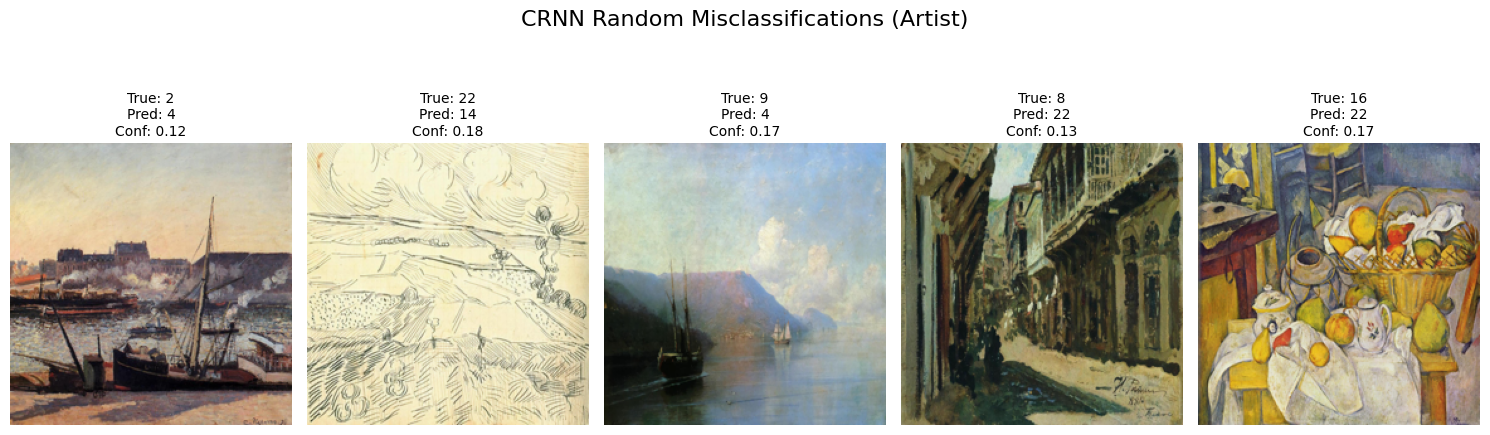

In [35]:
import numpy as np
import matplotlib.pyplot as plt

all_images = []
all_labels = []
for images_batch, labels_batch in test_data_tf:
    all_images.append(images_batch.numpy())
    all_labels.append(labels_batch[0].numpy())
all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

artist_preds_probs_crnn = crnn_model.predict(test_data_tf, verbose=0)[0]

misclassified_indices_crnn = np.where(y_true_np[0] != y_pred_crnn_classes[0])[0]

print(f"Total misclassified samples for Artist (CRNN): {len(misclassified_indices_crnn)}")

num_to_display = min(5, len(misclassified_indices_crnn))

if num_to_display > 0:
    np.random.shuffle(misclassified_indices_crnn)
    display_indices = misclassified_indices_crnn[:num_to_display]

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(display_indices):
        true_label = y_true_np[0][idx]
        predicted_label = y_pred_crnn_classes[0][idx]
        confidence = artist_preds_probs_crnn[idx, predicted_label]

        plt.subplot(1, num_to_display, i + 1)
        plt.imshow(all_images[idx])
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", fontsize=10)
    plt.tight_layout()
    plt.suptitle('CRNN Random Misclassifications (Artist)', y=1.05, fontsize=16)
    plt.show()
else:
    print("No misclassified samples found to display for CRNN.")

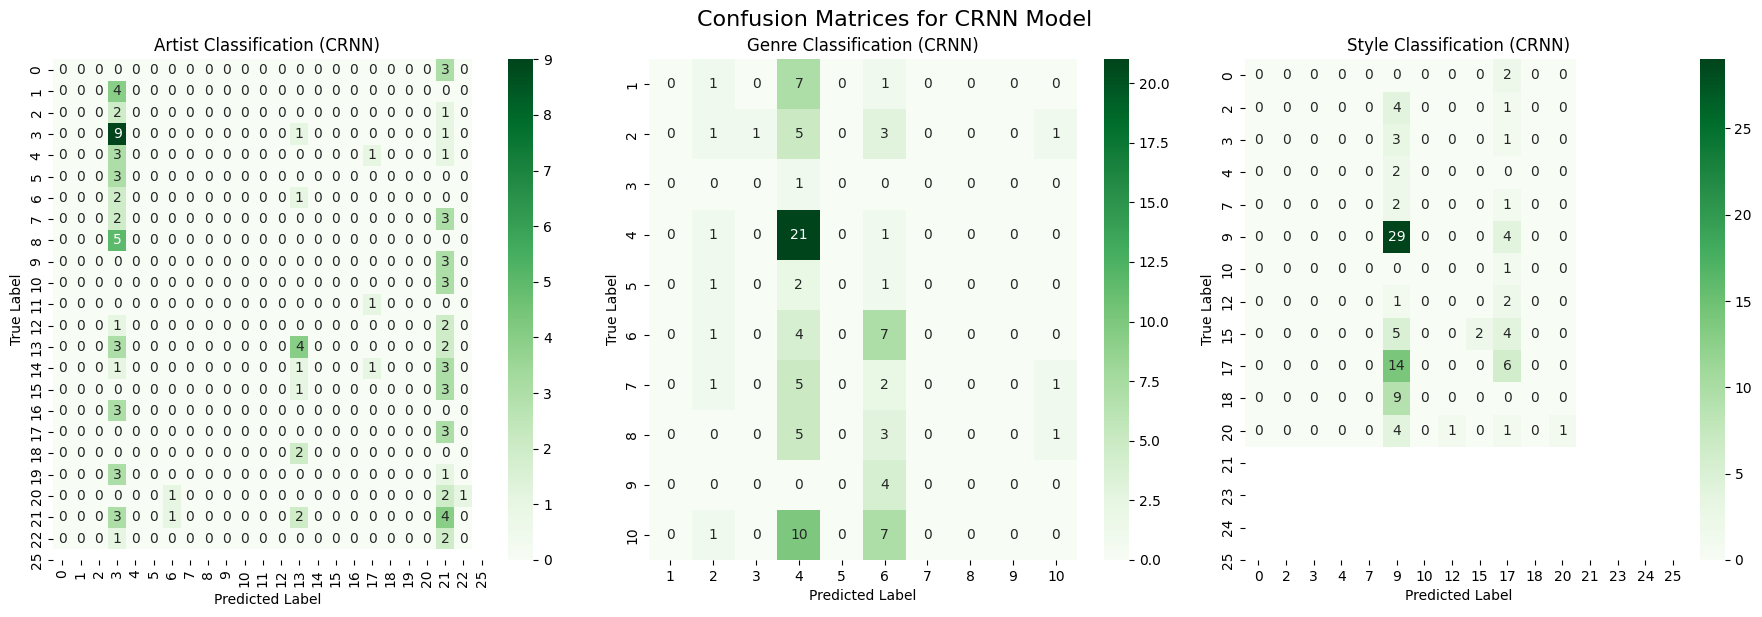

In [25]:
output_titles = ['Artist Classification (CRNN)', 'Genre Classification (CRNN)', 'Style Classification (CRNN)']

plt.figure(figsize=(18, 6))

for i in range(3):
    cm_crnn = confusion_matrix(y_true_np[i], y_pred_crnn_classes[i])

    current_class_names = all_class_names[['artist', 'genre', 'style'][i]]

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm_crnn, annot=True, fmt='d', cmap='Greens',
                xticklabels=current_class_names, yticklabels=current_class_names)
    plt.title(output_titles[i])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.suptitle('Confusion Matrices for CRNN Model', y=1.02, fontsize=16)
plt.show()